In [35]:
# =========================================================
# Cell 1. 기본 세팅
# =========================================================

# 처음 한 번만 설치
# !pip install pandas numpy pyreadstat scikit-learn statsmodels matplotlib openpyxl

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

In [36]:
# =========================================================
# Cell 2. 파일 경로 설정
# =========================================================

file_paths = {
    "funda": r"C:\Users\starw\OneDrive\바탕 화면\학교 생활\UNIST\Research\박지훈 자료\funda.sas7bdat",
    "fundq": r"C:\Users\starw\OneDrive\바탕 화면\학교 생활\UNIST\Research\박지훈 자료\fundq.sas7bdat",
    "mseall": r"C:\Users\starw\OneDrive\바탕 화면\학교 생활\UNIST\Research\박지훈 자료\mseall.sas7bdat",
    "msf": r"C:\Users\starw\OneDrive\바탕 화면\학교 생활\UNIST\Research\박지훈 자료\msf.sas7bdat"
}

for name, path in file_paths.items():
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{name}: {size_gb:.2f} GB")
    else:
        print(f"{name}: 파일 없음")

funda: 6.74 GB
fundq: 10.33 GB
mseall: 1.40 GB
msf: 0.81 GB


In [37]:
# =========================================================
# Cell 3. 공통 함수
# =========================================================

def read_sas_filtered(path, columns=None, chunksize=300_000, filter_func=None, encoding="latin1"):
    """
    대용량 sas7bdat 파일을 chunk 단위로 읽고,
    필요한 컬럼과 조건만 남기는 함수.
    """

    collected = []

    reader = pd.read_sas(
        path,
        format="sas7bdat",
        encoding=encoding,
        chunksize=chunksize
    )

    for i, chunk in enumerate(reader):
        print(f"chunk {i+1} 읽는 중: {chunk.shape}")

        chunk.columns = [str(c) for c in chunk.columns]

        if columns is not None:
            existing_cols = [c for c in columns if c in chunk.columns]
            chunk = chunk[existing_cols].copy()

        if filter_func is not None:
            chunk = filter_func(chunk)

        if len(chunk) > 0:
            collected.append(chunk)

    if len(collected) == 0:
        print("조건에 맞는 데이터가 없습니다.")
        return pd.DataFrame()

    result = pd.concat(collected, ignore_index=True)
    print("최종 데이터 크기:", result.shape)

    return result


def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)


def compound_return(ret_series):
    r = pd.to_numeric(ret_series, errors="coerce").dropna()
    if len(r) == 0:
        return np.nan
    return np.prod(1 + r) - 1


def max_drawdown_from_returns(ret_series):
    r = pd.to_numeric(ret_series, errors="coerce").dropna()
    if len(r) == 0:
        return np.nan

    wealth = (1 + r).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1

    return drawdown.min()


def winsorize_series(s, lower=0.01, upper=0.99):
    s = pd.to_numeric(s, errors="coerce")
    if s.notna().sum() < 20:
        return s
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    return s.clip(lo, hi)


def make_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

In [38]:
# =========================================================
# Cell 4. Compustat funda에서 엄격한 은행 표본 추출
# =========================================================

funda_cols = [
    "gvkey", "datadate", "fyear", "fyr",
    "indfmt", "consol", "popsrc", "datafmt",
    "tic", "cusip", "conm",
    "sich", "naicsh", "costat", "fic",
    "at", "ceq", "seq", "lt", "ni", "sale",
    "che", "dltt", "dlc", "prcc_f", "csho",
    "act", "lct"
]

STRICT_BANK_SIC = [6020, 6035, 6036]

def filter_funda_strict_banks(chunk):
    chunk["fyear"] = pd.to_numeric(chunk["fyear"], errors="coerce")

    # 2020: asset growth 계산용
    # 2021: pre-shock accounting variables
    chunk = chunk[chunk["fyear"].isin([2020, 2021])].copy()

    # 미국 기업만
    if "fic" in chunk.columns:
        chunk = chunk[chunk["fic"].eq("USA")].copy()

    # Compustat 표준 필터
    if "indfmt" in chunk.columns:
        chunk = chunk[chunk["indfmt"].eq("INDL")].copy()
    if "consol" in chunk.columns:
        chunk = chunk[chunk["consol"].eq("C")].copy()
    if "datafmt" in chunk.columns:
        chunk = chunk[chunk["datafmt"].eq("STD")].copy()

    # 엄격한 은행 표본
    if "sich" in chunk.columns:
        chunk["sich_num"] = pd.to_numeric(chunk["sich"], errors="coerce")
        chunk = chunk[chunk["sich_num"].isin(STRICT_BANK_SIC)].copy()

    return chunk


funda_bank_raw = read_sas_filtered(
    file_paths["funda"],
    columns=funda_cols,
    chunksize=300_000,
    filter_func=filter_funda_strict_banks
)

print("\n[funda_bank_raw]")
print(funda_bank_raw.shape)
display(funda_bank_raw.head())

print("\nSIC 분포:")
display(funda_bank_raw["sich_num"].value_counts().sort_index())

print("\n회사명 예시:")
display(funda_bank_raw[["gvkey", "fyear", "conm", "tic", "cusip", "sich_num"]].head(30))

chunk 1 읽는 중: (300000, 949)
chunk 2 읽는 중: (300000, 949)
chunk 3 읽는 중: (300000, 949)
chunk 4 읽는 중: (38671, 949)
최종 데이터 크기: (1072, 29)

[funda_bank_raw]
(1072, 29)


,gvkey,datadate,fyear,fyr,indfmt,consol,popsrc,datafmt,tic,cusip,conm,sich,naicsh,costat,fic,at,ceq,seq,lt,ni,sale,che,dltt,dlc,prcc_f,csho,act,lct,sich_num
0,002002,2020-12-31,"2,020.00000",12.00000,INDL,C,D,STD,BPOP,733174700,POPULAR INC,"6,020.00000","522,110.00000",A,USA,"65,926.00000","6,006.54400","6,028.68700","59,897.31300",506.62200,"2,603.86300","12,131.94500","1,350.10100",171.34300,56.32000,84.24400,NaN,NaN,"6,020.00000"
1,002002,2021-12-31,"2,021.00000",12.00000,INDL,C,D,STD,BPOP,733174700,POPULAR INC,"6,020.00000","522,110.00000",A,USA,"75,097.89900","5,947.25400","5,969.39700","69,128.50200",934.88900,"2,764.76500","17,965.15200","1,059.24800",269.75100,82.04000,79.85100,NaN,NaN,"6,020.00000"
2,002005,2020-12-31,"2,020.00000",12.00000,INDL,C,D,STD,BOH,062540109,BANK OF HAWAII CORP,"6,020.00000","522,110.00000",A,USA,"20,603.65100","1,374.50700","1,374.50700","19,229.14400",153.80400,730.83300,614.08800,167.89300,600.59000,76.62000,40.11900,NaN,NaN,"6,020.00000"
3,002005,2021-12-31,"2,021.00000",12.00000,INDL,C,D,STD,BOH,062540109,BANK OF HAWAII CORP,"6,020.00000","522,110.00000",A,USA,"22,784.94100","1,431.61100","1,611.61100","21,173.33000",253.37200,698.06900,560.43400,113.60100,450.49000,83.76000,40.25300,NaN,NaN,"6,020.00000"
4,002019,2020-12-31,"2,020.00000",12.00000,INDL,C,D,STD,BK,064058100,BANK OF NEW YORK MELLON CORP,"6,020.00000","522,110.00000",A,USA,"469,633.00000","41,260.00000","45,801.00000","423,513.00000","3,617.00000","16,940.00000","196,234.00000","22,806.00000","16,502.00000",42.44000,886.76400,NaN,NaN,"6,020.00000"



SIC 분포:


sich_num
6,020.00000    897
6,035.00000    108
6,036.00000     67
Name: count, dtype: int64


회사명 예시:


,gvkey,fyear,conm,tic,cusip,sich_num
0,002002,"2,020.00000",POPULAR INC,BPOP,733174700,"6,020.00000"
1,002002,"2,021.00000",POPULAR INC,BPOP,733174700,"6,020.00000"
2,002005,"2,020.00000",BANK OF HAWAII CORP,BOH,062540109,"6,020.00000"
3,002005,"2,021.00000",BANK OF HAWAII CORP,BOH,062540109,"6,020.00000"
4,002019,"2,020.00000",BANK OF NEW YORK MELLON CORP,BK,064058100,"6,020.00000"
5,002019,"2,021.00000",BANK OF NEW YORK MELLON CORP,BK,064058100,"6,020.00000"
6,002620,"2,020.00000",MUFG AMERICAS HOLDINGS CORP,0176A,62299A008,"6,020.00000"
7,002849,"2,020.00000",BBVA COMPASS BANCSHARES INC,BBVA1,05946K002,"6,020.00000"
8,002968,"2,020.00000",JPMORGAN CHASE & CO,JPM,46625H100,"6,020.00000"
9,002968,"2,021.00000",JPMORGAN CHASE & CO,JPM,46625H100,"6,020.00000"


In [39]:
# =========================================================
# Cell 5. 2021년 pre-shock 회계변수 생성
# =========================================================

funda_bank = funda_bank_raw.copy()

num_cols = [
    "fyear", "at", "ceq", "seq", "lt", "ni", "sale",
    "che", "dltt", "dlc", "prcc_f", "csho",
    "act", "lct", "sich_num"
]

for col in num_cols:
    if col in funda_bank.columns:
        funda_bank[col] = pd.to_numeric(funda_bank[col], errors="coerce")

# CUSIP 8자리 생성
funda_bank["cusip8"] = funda_bank["cusip"].astype(str).str[:8]

# 2020 총자산: asset growth 계산용
at_2020 = (
    funda_bank[funda_bank["fyear"] == 2020]
    [["gvkey", "at"]]
    .dropna(subset=["gvkey", "at"])
    .sort_values(["gvkey", "at"], ascending=[True, False])
    .drop_duplicates(subset=["gvkey"])
    .rename(columns={"at": "at_2020"})
)

# 2021 회계정보
x_2021 = funda_bank[funda_bank["fyear"] == 2021].copy()

# market cap 계산
x_2021["market_cap_compustat"] = x_2021["prcc_f"] * x_2021["csho"]

# 같은 gvkey-cusip8 중복 제거
x_2021 = (
    x_2021
    .sort_values(
        ["gvkey", "cusip8", "market_cap_compustat"],
        ascending=[True, True, False]
    )
    .drop_duplicates(subset=["gvkey", "cusip8"])
    .copy()
)

# 2020 자산 붙이기
x_2021 = x_2021.merge(at_2020, on="gvkey", how="left")

# 주요 변수 생성
x_2021["size"] = np.log(x_2021["at"])
x_2021["equity_ratio"] = safe_divide(x_2021["ceq"], x_2021["at"])
x_2021["roa"] = safe_divide(x_2021["ni"], x_2021["at"])
x_2021["cash_ratio"] = safe_divide(x_2021["che"], x_2021["at"])
x_2021["debt_ratio"] = safe_divide(x_2021["dltt"].fillna(0) + x_2021["dlc"].fillna(0), x_2021["at"])
x_2021["market_to_book"] = safe_divide(x_2021["market_cap_compustat"], x_2021["ceq"])
x_2021["asset_growth"] = safe_divide(x_2021["at"] - x_2021["at_2020"], x_2021["at_2020"])

# 참고용 변수: 메인 회귀에서는 제외
x_2021["leverage"] = safe_divide(x_2021["lt"], x_2021["at"])
x_2021["current_ratio"] = safe_divide(x_2021["act"], x_2021["lct"])

# 메인 설명변수
x_vars_main = [
    "size",
    "equity_ratio",
    "roa",
    "cash_ratio",
    "debt_ratio",
    "asset_growth",
    "market_to_book"
]

# 참고/부록용 변수
x_vars_extended = x_vars_main + [
    "leverage",
    "current_ratio"
]

x_data = x_2021[
    [
        "gvkey", "cusip", "cusip8", "tic", "conm",
        "sich_num", "naicsh", "at", "market_cap_compustat"
    ] + x_vars_extended
].copy()

x_data = x_data.replace([np.inf, -np.inf], np.nan)

print("x_data 크기:", x_data.shape)
print("고유 gvkey 수:", x_data["gvkey"].nunique())
print("고유 cusip8 수:", x_data["cusip8"].nunique())

display(x_data.head())
display(x_data[x_vars_extended].describe().T)

print("\nSIC 분포:")
display(x_data["sich_num"].value_counts().sort_index())

print("\n은행 회사명 예시:")
display(x_data[["gvkey", "conm", "tic", "sich_num", "cusip8"]].head(50))

x_data 크기: (523, 18)
고유 gvkey 수: 523
고유 cusip8 수: 523


,gvkey,cusip,cusip8,tic,conm,sich_num,naicsh,at,market_cap_compustat,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book,leverage,current_ratio
0,002002,733174700,73317470,BPOP,POPULAR INC,"6,020.00000","522,110.00000","75,097.89900","6,550.97604",11.22655,0.07919,0.01245,0.23922,0.01770,0.13912,1.10151,0.92051,NaN
1,002005,062540109,06254010,BOH,BANK OF HAWAII CORP,"6,020.00000","522,110.00000","22,784.94100","3,371.59128",10.03386,0.06283,0.01112,0.02460,0.02476,0.10587,2.35510,0.92927,NaN
2,002019,064058100,06405810,BK,BANK OF NEW YORK MELLON CORP,"6,020.00000","522,110.00000","444,438.00000","46,704.74160",13.00457,0.08594,0.00846,0.34823,0.08934,-0.05365,1.22277,0.90237,NaN
3,002968,46625H100,46625H10,JPM,JPMORGAN CHASE & CO,"6,020.00000","522,110.00000","3,743,567.00000","466,205.99415",15.13555,0.06926,0.01291,0.26780,0.14886,0.10558,1.79802,0.92143,NaN
4,003231,200340107,20034010,CMA,COMERICA INC,"6,020.00000","522,110.00000","94,616.00000","11,369.85600",11.45758,0.07930,0.01234,0.23970,0.03331,0.07361,1.51537,0.91654,NaN


,count,mean,std,min,25%,50%,75%,max
size,523.00000,8.10201,1.63206,4.60908,7.01101,7.79089,8.94464,15.13555
equity_ratio,523.00000,0.10485,0.03190,0.03966,0.08614,0.09889,0.11580,0.34465
roa,523.00000,0.01121,0.00601,-0.01899,0.00845,0.01078,0.01325,0.08307
cash_ratio,523.00000,0.11342,0.08509,0.00439,0.04950,0.09307,0.15242,0.54170
debt_ratio,523.00000,0.04520,0.04590,0.00000,0.01734,0.03285,0.05739,0.42792
asset_growth,507.00000,0.14399,0.18676,-0.34991,0.05358,0.10799,0.16927,1.86517
market_to_book,512.00000,1.23041,0.47093,0.37792,0.99017,1.14438,1.32683,5.32419
leverage,523.00000,0.89376,0.03150,0.65535,0.88348,0.90055,0.91256,0.94302
current_ratio,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SIC 분포:


sich_num
6,020.00000    441
6,035.00000     50
6,036.00000     32
Name: count, dtype: int64


은행 회사명 예시:


,gvkey,conm,tic,sich_num,cusip8
0,002002,POPULAR INC,BPOP,"6,020.00000",73317470
1,002005,BANK OF HAWAII CORP,BOH,"6,020.00000",06254010
2,002019,BANK OF NEW YORK MELLON CORP,BK,"6,020.00000",06405810
3,002968,JPMORGAN CHASE & CO,JPM,"6,020.00000",46625H10
4,003231,COMERICA INC,CMA,"6,020.00000",20034010
5,003238,COMMERCE BANCSHARES INC,CBSH,"6,020.00000",20052510
6,003643,CULLEN/FROST BANKERS INC,CFR,"6,020.00000",22989910
7,004640,FIFTH THIRD BANCORP,FITB,"6,020.00000",31677310
8,004674,REGIONS FINANCIAL CORP,RF,"6,020.00000",7591EP10
9,004685,TRUSTMARK CORP,TRMK,"6,020.00000",89840210


In [40]:
# =========================================================
# Cell 6. CRSP msf에서 2022-2023 수익률 추출
# =========================================================

msf_cols = [
    "CUSIP", "PERMNO", "PERMCO", "DATE",
    "RET", "RETX", "PRC", "SHROUT", "VOL",
    "HSICCD", "HEXCD"
]

shock_start = pd.Timestamp("2022-03-01")
shock_end = pd.Timestamp("2023-07-31")

def filter_msf_shock(chunk):
    chunk["DATE"] = pd.to_datetime(chunk["DATE"], errors="coerce")
    chunk = chunk[
        (chunk["DATE"] >= shock_start) &
        (chunk["DATE"] <= shock_end)
    ].copy()
    return chunk


msf_shock_raw = read_sas_filtered(
    file_paths["msf"],
    columns=msf_cols,
    chunksize=500_000,
    filter_func=filter_msf_shock
)

msf_shock = msf_shock_raw.copy()

msf_shock["CUSIP"] = msf_shock["CUSIP"].astype(str).str[:8]
msf_shock["PERMNO"] = pd.to_numeric(msf_shock["PERMNO"], errors="coerce")
msf_shock["PERMCO"] = pd.to_numeric(msf_shock["PERMCO"], errors="coerce")
msf_shock["RET"] = pd.to_numeric(msf_shock["RET"], errors="coerce")
msf_shock["RETX"] = pd.to_numeric(msf_shock["RETX"], errors="coerce")
msf_shock["PRC"] = pd.to_numeric(msf_shock["PRC"], errors="coerce")
msf_shock["SHROUT"] = pd.to_numeric(msf_shock["SHROUT"], errors="coerce")
msf_shock["VOL"] = pd.to_numeric(msf_shock["VOL"], errors="coerce")

# CRSP PRC는 음수일 수 있음. 시가총액 계산에는 절댓값 사용.
msf_shock["abs_prc"] = msf_shock["PRC"].abs()
msf_shock["mktcap_crsp"] = msf_shock["abs_prc"] * msf_shock["SHROUT"]

print("msf_shock 크기:", msf_shock.shape)
display(msf_shock.head())
display(msf_shock["DATE"].agg(["min", "max"]))

chunk 1 읽는 중: (500000, 21)
chunk 2 읽는 중: (500000, 21)
chunk 3 읽는 중: (500000, 21)
chunk 4 읽는 중: (500000, 21)
chunk 5 읽는 중: (500000, 21)
chunk 6 읽는 중: (500000, 21)
chunk 7 읽는 중: (500000, 21)
chunk 8 읽는 중: (500000, 21)
chunk 9 읽는 중: (500000, 21)
chunk 10 읽는 중: (500000, 21)
chunk 11 읽는 중: (153763, 21)
최종 데이터 크기: (163301, 11)
msf_shock 크기: (163301, 13)


,CUSIP,PERMNO,PERMCO,DATE,RET,RETX,PRC,SHROUT,VOL,HSICCD,HEXCD,abs_prc,mktcap_crsp
0,46603210,"10,026.00000","7,976.00000",2022-03-31,-0.04878,-0.05265,155.10001,"19,173.00000","14,867.00000","2,052.00000",3.00000,155.10001,"2,973,732.41702"
1,46603210,"10,026.00000","7,976.00000",2022-04-29,-0.03482,-0.03482,149.70000,"19,175.00000","12,125.00000","2,052.00000",3.00000,149.70000,"2,870,497.44148"
2,46603210,"10,026.00000","7,976.00000",2022-05-31,-0.14349,-0.14349,128.22000,"19,175.00000","28,299.00000","2,052.00000",3.00000,128.22000,"2,458,618.52341"
3,46603210,"10,026.00000","7,976.00000",2022-06-30,0.09416,0.08922,139.66000,"19,184.00000","23,187.00000","2,052.00000",3.00000,139.66000,"2,679,237.51025"
4,46603210,"10,026.00000","7,976.00000",2022-07-29,-0.02972,-0.02972,135.50999,"19,192.00000","14,940.00000","2,052.00000",3.00000,135.50999,"2,600,707.81458"


min   2022-03-31
max   2023-07-31
Name: DATE, dtype: datetime64[s]

In [41]:
# =========================================================
# Cell 7. mseall에서 CRSP 보조정보 및 delisting return 추출
# =========================================================

mseall_cols = [
    "DATE", "CUSIP", "NCUSIP", "COMNAM", "TICKER",
    "PERMNO", "PERMCO",
    "SHRCD", "EXCHCD", "SICCD", "NAICS",
    "TRDSTAT", "SECSTAT",
    "DLRET", "DLRETX", "DLSTCD"
]

def filter_mseall_shock(chunk):
    chunk["DATE"] = pd.to_datetime(chunk["DATE"], errors="coerce")
    chunk = chunk[
        (chunk["DATE"] >= shock_start) &
        (chunk["DATE"] <= shock_end)
    ].copy()
    return chunk


mseall_shock_raw = read_sas_filtered(
    file_paths["mseall"],
    columns=mseall_cols,
    chunksize=500_000,
    filter_func=filter_mseall_shock
)

mseall_shock = mseall_shock_raw.copy()

if len(mseall_shock) > 0:
    mseall_shock["CUSIP"] = mseall_shock["CUSIP"].astype(str).str[:8]
    mseall_shock["PERMNO"] = pd.to_numeric(mseall_shock["PERMNO"], errors="coerce")
    mseall_shock["PERMCO"] = pd.to_numeric(mseall_shock["PERMCO"], errors="coerce")
    mseall_shock["SHRCD"] = pd.to_numeric(mseall_shock["SHRCD"], errors="coerce")
    mseall_shock["EXCHCD"] = pd.to_numeric(mseall_shock["EXCHCD"], errors="coerce")
    mseall_shock["SICCD"] = pd.to_numeric(mseall_shock["SICCD"], errors="coerce")
    mseall_shock["DLRET"] = pd.to_numeric(mseall_shock["DLRET"], errors="coerce")
    mseall_shock["DLRETX"] = pd.to_numeric(mseall_shock["DLRETX"], errors="coerce")

    # 월별 delisting return
    dlret_monthly = (
        mseall_shock[
            ["PERMNO", "PERMCO", "DATE", "DLRET", "DLRETX", "DLSTCD"]
        ]
        .drop_duplicates(subset=["PERMNO", "DATE"])
        .copy()
    )

    # 기간 중 가장 최근 CRSP 정보
    crsp_info = (
        mseall_shock
        .sort_values(["PERMNO", "DATE"])
        .drop_duplicates(subset=["PERMNO"], keep="last")
        [[
            "PERMNO", "PERMCO", "CUSIP", "COMNAM", "TICKER",
            "SHRCD", "EXCHCD", "SICCD", "NAICS", "TRDSTAT", "SECSTAT"
        ]]
        .copy()
    )

else:
    dlret_monthly = pd.DataFrame()
    crsp_info = pd.DataFrame()

print("mseall_shock:", mseall_shock.shape)
print("dlret_monthly:", dlret_monthly.shape)
print("crsp_info:", crsp_info.shape)

display(crsp_info.head())

chunk 1 읽는 중: (500000, 50)
chunk 2 읽는 중: (500000, 50)
chunk 3 읽는 중: (500000, 50)
chunk 4 읽는 중: (500000, 50)
chunk 5 읽는 중: (500000, 50)
chunk 6 읽는 중: (500000, 50)
chunk 7 읽는 중: (500000, 50)
chunk 8 읽는 중: (244882, 50)
최종 데이터 크기: (155322, 16)
mseall_shock: (155322, 16)
dlret_monthly: (154036, 6)
crsp_info: (10394, 11)


,PERMNO,PERMCO,CUSIP,COMNAM,TICKER,SHRCD,EXCHCD,SICCD,NAICS,TRDSTAT,SECSTAT
14,"10,026.00000","7,976.00000",46603210,J & J SNACK FOODS CORP,JJSF,11.00000,3.00000,"2,052.00000",311930,A,R
31,"10,028.00000","7,978.00000",29402E10,ENVELA CORP,ELA,11.00000,2.00000,"5,094.00000",423940,A,R
45,"10,032.00000","7,980.00000",72913210,PLEXUS CORP,PLXS,11.00000,3.00000,"3,670.00000",334418,A,R
61,"10,044.00000","7,992.00000",77467X10,ROCKY MOUNTAIN CHOC FAC INC NEW,RMCF,11.00000,3.00000,"2,060.00000",445292,A,R
69,"10,051.00000","7,999.00000",41043F20,HANGER INC,HNGR,11.00000,1.00000,"4,813.00000",621498,A,R


In [42]:
# =========================================================
# Cell 8. delisting-adjusted return 생성
# =========================================================

msf_adj = msf_shock.copy()

if len(dlret_monthly) > 0:
    msf_adj = msf_adj.merge(
        dlret_monthly,
        on=["PERMNO", "PERMCO", "DATE"],
        how="left"
    )
else:
    msf_adj["DLRET"] = np.nan
    msf_adj["DLRETX"] = np.nan
    msf_adj["DLSTCD"] = np.nan

# RET + DLRET 결합
# 1) RET 있고 DLRET 없으면 RET
# 2) RET 있고 DLRET 있으면 (1+RET)*(1+DLRET)-1
# 3) RET 없고 DLRET 있으면 DLRET
# 4) 둘 다 없으면 NaN

msf_adj["ret_adj"] = np.nan

cond_ret_only = msf_adj["RET"].notna() & msf_adj["DLRET"].isna()
cond_both = msf_adj["RET"].notna() & msf_adj["DLRET"].notna()
cond_dlret_only = msf_adj["RET"].isna() & msf_adj["DLRET"].notna()

msf_adj.loc[cond_ret_only, "ret_adj"] = msf_adj.loc[cond_ret_only, "RET"]
msf_adj.loc[cond_both, "ret_adj"] = (
    (1 + msf_adj.loc[cond_both, "RET"]) *
    (1 + msf_adj.loc[cond_both, "DLRET"]) - 1
)
msf_adj.loc[cond_dlret_only, "ret_adj"] = msf_adj.loc[cond_dlret_only, "DLRET"]

# RETX도 동일하게 보조 생성
msf_adj["retx_adj"] = np.nan

cond_retx_only = msf_adj["RETX"].notna() & msf_adj["DLRETX"].isna()
cond_retx_both = msf_adj["RETX"].notna() & msf_adj["DLRETX"].notna()
cond_dlretx_only = msf_adj["RETX"].isna() & msf_adj["DLRETX"].notna()

msf_adj.loc[cond_retx_only, "retx_adj"] = msf_adj.loc[cond_retx_only, "RETX"]
msf_adj.loc[cond_retx_both, "retx_adj"] = (
    (1 + msf_adj.loc[cond_retx_both, "RETX"]) *
    (1 + msf_adj.loc[cond_retx_both, "DLRETX"]) - 1
)
msf_adj.loc[cond_dlretx_only, "retx_adj"] = msf_adj.loc[cond_dlretx_only, "DLRETX"]

print("ret_adj 결측률:", msf_adj["ret_adj"].isna().mean())
print("DLRET 존재 행 수:", msf_adj["DLRET"].notna().sum())

display(msf_adj[["PERMNO", "DATE", "RET", "DLRET", "ret_adj", "PRC", "SHROUT", "mktcap_crsp"]].head())

ret_adj 결측률: 0.012902554179092595
DLRET 존재 행 수: 1081


,PERMNO,DATE,RET,DLRET,ret_adj,PRC,SHROUT,mktcap_crsp
0,"10,026.00000",2022-03-31,-0.04878,NaN,-0.04878,155.10001,"19,173.00000","2,973,732.41702"
1,"10,026.00000",2022-04-29,-0.03482,NaN,-0.03482,149.70000,"19,175.00000","2,870,497.44148"
2,"10,026.00000",2022-05-31,-0.14349,NaN,-0.14349,128.22000,"19,175.00000","2,458,618.52341"
3,"10,026.00000",2022-06-30,0.09416,NaN,0.09416,139.66000,"19,184.00000","2,679,237.51025"
4,"10,026.00000",2022-07-29,-0.02972,NaN,-0.02972,135.50999,"19,192.00000","2,600,707.81458"


In [43]:
# =========================================================
# Cell 9. 은행 회계변수와 CRSP 수익률 연결
# =========================================================

linked_monthly = msf_adj.merge(
    x_data,
    left_on="CUSIP",
    right_on="cusip8",
    how="inner"
)

print("CUSIP 연결 후:", linked_monthly.shape)
print("연결된 고유 gvkey:", linked_monthly["gvkey"].nunique())
print("연결된 고유 PERMNO:", linked_monthly["PERMNO"].nunique())

# CRSP 정보 붙이기
if len(crsp_info) > 0:
    crsp_info_to_merge = crsp_info.drop(columns=["CUSIP"], errors="ignore")

    linked_monthly = linked_monthly.merge(
        crsp_info_to_merge,
        on=["PERMNO", "PERMCO"],
        how="left"
    )

    # 보통주만 유지
    before = len(linked_monthly)
    linked_monthly = linked_monthly[
        linked_monthly["SHRCD"].isna() |
        linked_monthly["SHRCD"].isin([10, 11])
    ].copy()
    print(f"SHRCD 보통주 필터: {before:,} -> {len(linked_monthly):,}")

    # NYSE, AMEX, NASDAQ만 유지
    before = len(linked_monthly)
    linked_monthly = linked_monthly[
        linked_monthly["EXCHCD"].isna() |
        linked_monthly["EXCHCD"].isin([1, 2, 3])
    ].copy()
    print(f"EXCHCD 필터: {before:,} -> {len(linked_monthly):,}")

# ret_adj가 없는 행 제거
linked_monthly = linked_monthly.dropna(subset=["ret_adj"]).copy()

print("최종 linked_monthly:", linked_monthly.shape)
print("최종 고유 gvkey:", linked_monthly["gvkey"].nunique())
print("최종 고유 PERMNO:", linked_monthly["PERMNO"].nunique())

display(linked_monthly.head())

print("\n연결된 은행 예시:")
display(
    linked_monthly[
        ["gvkey", "PERMNO", "conm", "tic", "CUSIP", "DATE", "ret_adj", "sich_num"]
    ]
    .drop_duplicates(subset=["gvkey", "PERMNO"])
    .head(50)
)

CUSIP 연결 후: (5879, 36)
연결된 고유 gvkey: 359
연결된 고유 PERMNO: 359
SHRCD 보통주 필터: 5,879 -> 5,879
EXCHCD 필터: 5,879 -> 5,879
최종 linked_monthly: (5867, 44)
최종 고유 gvkey: 359
최종 고유 PERMNO: 359


,CUSIP,PERMNO,PERMCO,DATE,RET,RETX,PRC,SHROUT,VOL,HSICCD,HEXCD,abs_prc,mktcap_crsp,DLRET,DLRETX,DLSTCD,ret_adj,retx_adj,gvkey,cusip,cusip8,tic,conm,sich_num,naicsh,at,market_cap_compustat,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book,leverage,current_ratio,COMNAM,TICKER,SHRCD,EXCHCD,SICCD,NAICS,TRDSTAT,SECSTAT
0,45383610,"10,252.00000","8,179.00000",2022-03-31,-0.04430,-0.05023,81.69000,"47,377.00000","44,515.00000","6,020.00000",3.00000,81.69000,"3,870,227.24567",NaN,NaN,NaN,-0.04430,-0.05023,016889,453836108,45383610,INDB,INDEPENDENT BANK CORP/MA,"6,020.00000","522,110.00000","20,423.40500","3,860.44550",9.92444,0.14779,0.00592,0.10971,0.01059,0.54672,1.27895,0.85221,NaN,INDEPENDENT BANK CORP MA,INDB,11.00000,3.00000,"6,020.00000",522110,A,R
1,45383610,"10,252.00000","8,179.00000",2022-04-29,-0.05545,-0.05545,77.16000,"47,377.00000","43,075.00000","6,020.00000",3.00000,77.16000,"3,655,609.49350",NaN,NaN,NaN,-0.05545,-0.05545,016889,453836108,45383610,INDB,INDEPENDENT BANK CORP/MA,"6,020.00000","522,110.00000","20,423.40500","3,860.44550",9.92444,0.14779,0.00592,0.10971,0.01059,0.54672,1.27895,0.85221,NaN,INDEPENDENT BANK CORP MA,INDB,11.00000,3.00000,"6,020.00000",522110,A,R
2,45383610,"10,252.00000","8,179.00000",2022-05-31,0.07957,0.07957,83.30000,"46,779.00000","39,538.00000","6,020.00000",3.00000,83.30000,"3,896,690.84276",NaN,NaN,NaN,0.07957,0.07957,016889,453836108,45383610,INDB,INDEPENDENT BANK CORP/MA,"6,020.00000","522,110.00000","20,423.40500","3,860.44550",9.92444,0.14779,0.00592,0.10971,0.01059,0.54672,1.27895,0.85221,NaN,INDEPENDENT BANK CORP MA,INDB,11.00000,3.00000,"6,020.00000",522110,A,R
3,45383610,"10,252.00000","8,179.00000",2022-06-30,-0.04034,-0.04646,79.43000,"46,070.00000","43,336.00000","6,020.00000",3.00000,79.43000,"3,659,340.11406",NaN,NaN,NaN,-0.04034,-0.04646,016889,453836108,45383610,INDB,INDEPENDENT BANK CORP/MA,"6,020.00000","522,110.00000","20,423.40500","3,860.44550",9.92444,0.14779,0.00592,0.10971,0.01059,0.54672,1.27895,0.85221,NaN,INDEPENDENT BANK CORP MA,INDB,11.00000,3.00000,"6,020.00000",522110,A,R
4,45383610,"10,252.00000","8,179.00000",2022-07-29,0.05502,0.05502,83.80000,"46,070.00000","39,172.00000","6,020.00000",3.00000,83.80000,"3,860,666.14059",NaN,NaN,NaN,0.05502,0.05502,016889,453836108,45383610,INDB,INDEPENDENT BANK CORP/MA,"6,020.00000","522,110.00000","20,423.40500","3,860.44550",9.92444,0.14779,0.00592,0.10971,0.01059,0.54672,1.27895,0.85221,NaN,INDEPENDENT BANK CORP MA,INDB,11.00000,3.00000,"6,020.00000",522110,A,R



연결된 은행 예시:


,gvkey,PERMNO,conm,tic,CUSIP,DATE,ret_adj,sich_num
0,016889,"10,252.00000",INDEPENDENT BANK CORP/MA,INDB,45383610,2022-03-31,-0.04430,"6,020.00000"
17,017240,"10,308.00000",TOMPKINS FINANCIAL CORP,TMP,89011010,2022-03-31,-0.01049,"6,020.00000"
34,018049,"10,629.00000",F N B CORP/FL,FNB,30252010,2022-03-31,-0.06404,"6,020.00000"
51,004690,"10,777.00000",FIRST CITIZENS BANCSH -CL A,FCNCA,31946M10,2022-03-31,-0.15581,"6,020.00000"
68,017641,"10,781.00000",BANK SOUTH CAROLINA CORP,BKSC,06506610,2022-03-31,-0.06050,"6,020.00000"
85,017132,"10,892.00000",WSFS FINANCIAL CORP,WSFS,92932810,2022-03-31,-0.08283,"6,035.00000"
102,017150,"10,932.00000",WEBSTER FINANCIAL CORP,WBS,94789010,2022-03-31,-0.06793,"6,020.00000"
119,018307,"11,006.00000",FIRST LONG ISLAND CORP,FLIC,32073410,2022-03-31,-0.09692,"6,020.00000"
136,016821,"11,018.00000",FIRST BANCORP P R,FBP,31867270,2022-03-31,-0.07082,"6,020.00000"
153,016981,"11,208.00000",OFG BANCORP,OFG,67103X10,2022-03-31,-0.04933,"6,020.00000"


In [44]:
# =========================================================
# Cell 10. 은행 벤치마크 수익률 생성
# =========================================================

monthly_for_bench = linked_monthly.copy()

# PERMNO-DATE 중복 제거
monthly_for_bench = (
    monthly_for_bench
    .sort_values(["PERMNO", "DATE", "mktcap_crsp"], ascending=[True, True, False])
    .drop_duplicates(subset=["PERMNO", "DATE"])
    .copy()
)

# equal-weight 은행 벤치마크
ew_bench = (
    monthly_for_bench
    .groupby("DATE", as_index=False)
    .agg(ew_bank_ret=("ret_adj", "mean"))
)

# value-weight 은행 벤치마크
def value_weighted_return(group):
    temp = group.dropna(subset=["ret_adj", "mktcap_crsp"]).copy()
    temp = temp[temp["mktcap_crsp"] > 0]

    if len(temp) == 0:
        return np.nan

    return np.average(temp["ret_adj"], weights=temp["mktcap_crsp"])

vw_bench = (
    monthly_for_bench
    .groupby("DATE")
    .apply(value_weighted_return)
    .reset_index(name="vw_bank_ret")
)

bank_bench = ew_bench.merge(vw_bench, on="DATE", how="outer")

linked_monthly = linked_monthly.merge(
    bank_bench,
    on="DATE",
    how="left"
)

# 월별 abnormal return
linked_monthly["ew_bank_adj_ret"] = linked_monthly["ret_adj"] - linked_monthly["ew_bank_ret"]
linked_monthly["vw_bank_adj_ret"] = linked_monthly["ret_adj"] - linked_monthly["vw_bank_ret"]

display(bank_bench.head())
display(linked_monthly[["PERMNO", "DATE", "ret_adj", "ew_bank_ret", "vw_bank_ret", "ew_bank_adj_ret", "vw_bank_adj_ret"]].head())

,DATE,ew_bank_ret,vw_bank_ret
0,2022-03-31,-0.02401,-0.05816
1,2022-04-29,-0.06021,-0.10912
2,2022-05-31,0.02014,0.06391
3,2022-06-30,-0.05674,-0.11888
4,2022-07-29,0.05480,0.07618


,PERMNO,DATE,ret_adj,ew_bank_ret,vw_bank_ret,ew_bank_adj_ret,vw_bank_adj_ret
0,"10,252.00000",2022-03-31,-0.04430,-0.02401,-0.05816,-0.02029,0.01386
1,"10,252.00000",2022-04-29,-0.05545,-0.06021,-0.10912,0.00476,0.05366
2,"10,252.00000",2022-05-31,0.07957,0.02014,0.06391,0.05943,0.01566
3,"10,252.00000",2022-06-30,-0.04034,-0.05674,-0.11888,0.01641,0.07854
4,"10,252.00000",2022-07-29,0.05502,0.05480,0.07618,0.00022,-0.02116


In [45]:
# =========================================================
# Cell 11. 기간별 Y변수 생성
# =========================================================

periods = {
    "202203_202303": (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-03-31"), 10),
    "202203_202307": (pd.Timestamp("2022-03-01"), pd.Timestamp("2023-07-31"), 13),
    "202303": (pd.Timestamp("2023-03-01"), pd.Timestamp("2023-03-31"), 1)
}

def make_y_by_period(df, period_name, start, end, min_months):
    temp = df[
        (df["DATE"] >= start) &
        (df["DATE"] <= end)
    ].copy()

    y = (
        temp
        .groupby(["gvkey", "PERMNO"], as_index=False)
        .agg(
            raw_cum_ret=("ret_adj", compound_return),
            ew_adj_cum_ret=("ew_bank_adj_ret", compound_return),
            vw_adj_cum_ret=("vw_bank_adj_ret", compound_return),
            max_drawdown=("ret_adj", max_drawdown_from_returns),
            n_months=("ret_adj", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
            first_date=("DATE", "min"),
            last_date=("DATE", "max"),
            avg_mktcap_crsp=("mktcap_crsp", "mean")
        )
    )

    y = y[y["n_months"] >= min_months].copy()

    rename_dict = {
        "raw_cum_ret": f"raw_cum_ret_{period_name}",
        "ew_adj_cum_ret": f"ew_adj_cum_ret_{period_name}",
        "vw_adj_cum_ret": f"vw_adj_cum_ret_{period_name}",
        "max_drawdown": f"max_drawdown_{period_name}",
        "n_months": f"n_months_{period_name}",
        "first_date": f"first_date_{period_name}",
        "last_date": f"last_date_{period_name}",
        "avg_mktcap_crsp": f"avg_mktcap_crsp_{period_name}"
    }

    y = y.rename(columns=rename_dict)

    return y


y_data = {}

for period_name, (start, end, min_months) in periods.items():
    y_data[period_name] = make_y_by_period(
        linked_monthly,
        period_name,
        start,
        end,
        min_months
    )
    print(period_name, y_data[period_name].shape)
    display(y_data[period_name].head())

y_main = y_data["202203_202303"]
y_extended = y_data["202203_202307"]
y_march = y_data["202303"]

202203_202303 (343, 10)


,gvkey,PERMNO,raw_cum_ret_202203_202303,ew_adj_cum_ret_202203_202303,vw_adj_cum_ret_202203_202303,max_drawdown_202203_202303,n_months_202203_202303,first_date_202203_202303,last_date_202203_202303,avg_mktcap_crsp_202203_202303
0,002002,"16,505.00000",-0.34995,-0.17757,-0.19400,-0.27443,13,2022-03-31,2023-03-31,"5,442,296.99138"
1,002005,"16,548.00000",-0.37375,-0.17992,-0.19681,-0.35689,13,2022-03-31,2023-03-31,"3,039,348.05951"
2,002019,"49,656.00000",-0.11676,0.12482,0.12955,-0.21092,13,2022-03-31,2023-03-31,"36,262,662.06554"
3,002968,"47,896.00000",-0.05114,0.21320,0.22209,-0.22030,13,2022-03-31,2023-03-31,"372,053,074.43750"
4,003231,"25,081.00000",-0.52075,-0.35639,-0.36610,-0.49771,13,2022-03-31,2023-03-31,"9,610,281.89320"


202203_202307 (339, 10)


,gvkey,PERMNO,raw_cum_ret_202203_202307,ew_adj_cum_ret_202203_202307,vw_adj_cum_ret_202203_202307,max_drawdown_202203_202307,n_months_202203_202307,first_date_202203_202307,last_date_202203_202307,avg_mktcap_crsp_202203_202307
0,002002,"16,505.00000",-0.17062,-0.02012,-0.10727,-0.27443,17,2022-03-31,2023-07-31,"5,222,287.84131"
1,002005,"16,548.00000",-0.30074,-0.11429,-0.20563,-0.50791,17,2022-03-31,2023-07-31,"2,758,139.60003"
2,002019,"49,656.00000",-0.10242,0.05341,-0.02005,-0.21092,17,2022-03-31,2023-07-31,"35,783,298.80763"
3,002968,"47,896.00000",0.16585,0.37134,0.28966,-0.22030,17,2022-03-31,2023-07-31,"383,928,573.42471"
4,003231,"25,081.00000",-0.39443,-0.21953,-0.29067,-0.58239,17,2022-03-31,2023-07-31,"8,710,115.23295"


202303 (341, 10)


,gvkey,PERMNO,raw_cum_ret_202303,ew_adj_cum_ret_202303,vw_adj_cum_ret_202303,max_drawdown_202303,n_months_202303,first_date_202303,last_date_202303,avg_mktcap_crsp_202303
0,002002,"16,505.00000",-0.18824,-0.01158,-0.02762,0.00000,1,2023-03-31,2023-03-31,"4,131,568.04902"
1,002005,"16,548.00000",-0.30430,-0.12764,-0.14368,0.00000,1,2023-03-31,2023-03-31,"2,072,002.87285"
2,002019,"49,656.00000",-0.10692,0.06974,0.05370,0.00000,1,2023-03-31,2023-03-31,"36,542,892.33560"
3,002968,"47,896.00000",-0.09097,0.08569,0.06965,0.00000,1,2023-03-31,2023-03-31,"383,548,582.86407"
4,003231,"25,081.00000",-0.37047,-0.19381,-0.20985,0.00000,1,2023-03-31,2023-03-31,"5,703,347.01949"


In [46]:
# =========================================================
# Cell 12. 최종 분석 샘플 생성
# =========================================================

firm_info_cols = [
    "gvkey", "PERMNO", "cusip8", "tic", "conm",
    "sich_num", "naicsh", "at", "market_cap_compustat"
] + x_vars_extended

firm_info = (
    linked_monthly[firm_info_cols]
    .drop_duplicates(subset=["gvkey", "PERMNO"])
    .copy()
)

analysis_df = y_main.merge(
    firm_info,
    on=["gvkey", "PERMNO"],
    how="left"
)

analysis_df = analysis_df.merge(
    y_extended,
    on=["gvkey", "PERMNO"],
    how="left"
)

analysis_df = analysis_df.merge(
    y_march,
    on=["gvkey", "PERMNO"],
    how="left"
)

# 같은 gvkey에 여러 PERMNO가 있으면 가장 관측월 많고 평균 시가총액 큰 것 사용
analysis_df = (
    analysis_df
    .sort_values(
        ["gvkey", "n_months_202203_202303", "avg_mktcap_crsp_202203_202303"],
        ascending=[True, False, False]
    )
    .drop_duplicates(subset=["gvkey"])
    .copy()
)

print("analysis_df:", analysis_df.shape)
print("고유 은행 수:", analysis_df["gvkey"].nunique())

print("\nSIC 분포:")
display(analysis_df["sich_num"].value_counts().sort_index())

display(
    analysis_df[
        [
            "gvkey", "PERMNO", "conm", "tic", "sich_num",
            "raw_cum_ret_202203_202303",
            "ew_adj_cum_ret_202203_202303",
            "vw_adj_cum_ret_202203_202303",
            "max_drawdown_202203_202303"
        ] + x_vars_main
    ].head(30)
)

analysis_df: (343, 42)
고유 은행 수: 343

SIC 분포:


sich_num
6,020.00000    287
6,035.00000     33
6,036.00000     23
Name: count, dtype: int64

,gvkey,PERMNO,conm,tic,sich_num,raw_cum_ret_202203_202303,ew_adj_cum_ret_202203_202303,vw_adj_cum_ret_202203_202303,max_drawdown_202203_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book
0,002002,"16,505.00000",POPULAR INC,BPOP,"6,020.00000",-0.34995,-0.17757,-0.19400,-0.27443,11.22655,0.07919,0.01245,0.23922,0.01770,0.13912,1.10151
1,002005,"16,548.00000",BANK OF HAWAII CORP,BOH,"6,020.00000",-0.37375,-0.17992,-0.19681,-0.35689,10.03386,0.06283,0.01112,0.02460,0.02476,0.10587,2.35510
2,002019,"49,656.00000",BANK OF NEW YORK MELLON CORP,BK,"6,020.00000",-0.11676,0.12482,0.12955,-0.21092,13.00457,0.08594,0.00846,0.34823,0.08934,-0.05365,1.22277
3,002968,"47,896.00000",JPMORGAN CHASE & CO,JPM,"6,020.00000",-0.05114,0.21320,0.22209,-0.22030,15.13555,0.06926,0.01291,0.26780,0.14886,0.10558,1.79802
4,003231,"25,081.00000",COMERICA INC,CMA,"6,020.00000",-0.52075,-0.35639,-0.36610,-0.49771,11.45758,0.07930,0.01234,0.23970,0.03331,0.07361,1.51537
5,003238,"25,129.00000",COMMERCE BANCSHARES INC,CBSH,"6,020.00000",-0.12918,0.08847,0.06501,-0.17540,10.51023,0.09369,0.01447,0.11664,0.08348,0.11439,2.43347
6,003643,"27,888.00000",CULLEN/FROST BANKERS INC,CFR,"6,020.00000",-0.23236,-0.01578,-0.03751,-0.31202,10.83720,0.08440,0.00871,0.32593,0.06491,0.20021,1.87856
7,004640,"34,746.00000",FIFTH THIRD BANCORP,FITB,"6,020.00000",-0.41551,-0.23047,-0.22992,-0.35483,12.26016,0.09518,0.01312,0.17794,0.06443,0.03144,1.47979
8,004674,"35,044.00000",REGIONS FINANCIAL CORP,RF,"6,020.00000",-0.19622,0.04204,0.04210,-0.20306,12.00113,0.10229,0.01547,0.18050,0.01802,0.10550,1.23199
9,004685,"35,263.00000",TRUSTMARK CORP,TRMK,"6,020.00000",-0.19238,0.02737,0.00100,-0.31949,9.77541,0.09896,0.00838,0.12883,0.03131,0.06306,1.14921


In [47]:
# =========================================================
# Cell 13. 회귀분석용 데이터 정리
# =========================================================

main_y = "vw_adj_cum_ret_202203_202303"

y_vars = [
    "raw_cum_ret_202203_202303",
    "ew_adj_cum_ret_202203_202303",
    "vw_adj_cum_ret_202203_202303",
    "max_drawdown_202203_202303",
    "raw_cum_ret_202203_202307",
    "ew_adj_cum_ret_202203_202307",
    "vw_adj_cum_ret_202203_202307",
    "max_drawdown_202203_202307",
    "raw_cum_ret_202303",
    "ew_adj_cum_ret_202303",
    "vw_adj_cum_ret_202303",
    "max_drawdown_202303"
]

reg_cols = [
    "gvkey", "PERMNO", "conm", "tic", "cusip8",
    "sich_num", "naicsh"
] + y_vars + x_vars_extended

reg_df = analysis_df[reg_cols].copy()
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)

for col in y_vars + x_vars_extended:
    if col in reg_df.columns:
        reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

# winsorize
for col in y_vars + x_vars_extended:
    if col in reg_df.columns:
        reg_df[col] = winsorize_series(reg_df[col], 0.01, 0.99)

reg_main = reg_df.dropna(subset=[main_y] + x_vars_main).copy()

print("reg_df:", reg_df.shape)
print("reg_main:", reg_main.shape)

print("\nSIC 분포:")
display(reg_main["sich_num"].value_counts().sort_index())

display(reg_main.head())
display(reg_main[[main_y] + x_vars_main].describe().T)

print("\n상관관계:")
display(reg_main[[main_y] + x_vars_main].corr())

reg_df: (343, 28)
reg_main: (340, 28)

SIC 분포:


sich_num
6,020.00000    286
6,035.00000     31
6,036.00000     23
Name: count, dtype: int64

,gvkey,PERMNO,conm,tic,cusip8,sich_num,naicsh,raw_cum_ret_202203_202303,ew_adj_cum_ret_202203_202303,vw_adj_cum_ret_202203_202303,max_drawdown_202203_202303,raw_cum_ret_202203_202307,ew_adj_cum_ret_202203_202307,vw_adj_cum_ret_202203_202307,max_drawdown_202203_202307,raw_cum_ret_202303,ew_adj_cum_ret_202303,vw_adj_cum_ret_202303,max_drawdown_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book,leverage,current_ratio
0,002002,"16,505.00000",POPULAR INC,BPOP,73317470,"6,020.00000","522,110.00000",-0.34995,-0.17757,-0.19400,-0.27443,-0.17062,-0.02012,-0.10727,-0.27443,-0.18824,-0.01158,-0.02762,0.00000,11.22655,0.07919,0.01245,0.23922,0.01770,0.13912,1.10151,0.92051,NaN
1,002005,"16,548.00000",BANK OF HAWAII CORP,BOH,06254010,"6,020.00000","522,110.00000",-0.37375,-0.17992,-0.19681,-0.35689,-0.30074,-0.11429,-0.20563,-0.50791,-0.30430,-0.12764,-0.14368,0.00000,10.03386,0.06283,0.01112,0.02460,0.02476,0.10587,2.35510,0.92927,NaN
2,002019,"49,656.00000",BANK OF NEW YORK MELLON CORP,BK,06405810,"6,020.00000","522,110.00000",-0.11676,0.12482,0.12955,-0.21092,-0.10242,0.05341,-0.02005,-0.21092,-0.10692,0.06974,0.05370,0.00000,13.00457,0.08594,0.00846,0.34823,0.08934,-0.05365,1.22277,0.90237,NaN
3,002968,"47,896.00000",JPMORGAN CHASE & CO,JPM,46625H10,"6,020.00000","522,110.00000",-0.05114,0.21320,0.22209,-0.22030,0.16585,0.37134,0.28966,-0.22030,-0.09097,0.08569,0.06965,0.00000,13.24718,0.06926,0.01291,0.26780,0.14886,0.10558,1.79802,0.92143,NaN
4,003231,"25,081.00000",COMERICA INC,CMA,20034010,"6,020.00000","522,110.00000",-0.52075,-0.35639,-0.36610,-0.49771,-0.39443,-0.21953,-0.29067,-0.58239,-0.37047,-0.19381,-0.20985,0.00000,11.45758,0.07930,0.01234,0.23970,0.03331,0.07361,1.51537,0.91654,NaN


,count,mean,std,min,25%,50%,75%,max
vw_adj_cum_ret_202203_202303,340.00000,-0.01514,0.20708,-0.64258,-0.14738,-0.01431,0.11810,0.46783
size,340.00000,8.58988,1.52018,5.78212,7.52809,8.36380,9.46653,13.24718
equity_ratio,340.00000,0.10801,0.03118,0.06279,0.08913,0.10142,0.11767,0.26352
roa,340.00000,0.01132,0.00403,-0.00013,0.00882,0.01136,0.01372,0.02155
cash_ratio,340.00000,0.10868,0.07894,0.00897,0.04871,0.09014,0.14555,0.37577
debt_ratio,340.00000,0.04456,0.03683,0.00002,0.02061,0.03488,0.05767,0.18322
asset_growth,340.00000,0.14937,0.18239,-0.06852,0.05155,0.09871,0.17558,1.01630
market_to_book,340.00000,1.29592,0.47007,0.68089,1.02787,1.18923,1.38095,3.50865



상관관계:


,vw_adj_cum_ret_202203_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book
vw_adj_cum_ret_202203_202303,1.00000,-0.18037,0.05613,-0.00817,0.18556,-0.12540,-0.10462,-0.23705
size,-0.18037,1.00000,-0.23297,0.18920,0.05272,0.12957,-0.00344,0.29539
equity_ratio,0.05613,-0.23297,1.00000,-0.02745,-0.06271,0.02963,-0.10741,-0.21364
roa,-0.00817,0.18920,-0.02745,1.00000,-0.09521,-0.03168,-0.17613,0.33120
cash_ratio,0.18556,0.05272,-0.06271,-0.09521,1.00000,-0.13092,0.23362,0.10498
debt_ratio,-0.12540,0.12957,0.02963,-0.03168,-0.13092,1.00000,-0.18246,0.04295
asset_growth,-0.10462,-0.00344,-0.10741,-0.17613,0.23362,-0.18246,1.00000,0.18941
market_to_book,-0.23705,0.29539,-0.21364,0.33120,0.10498,0.04295,0.18941,1.00000


In [48]:
# =========================================================
# Cell 14. 표본 진단
# =========================================================

print("최종 메인 회귀 표본 수:", reg_main.shape[0])
print("고유 gvkey:", reg_main["gvkey"].nunique())
print("고유 PERMNO:", reg_main["PERMNO"].nunique())

print("\nSIC 분포:")
display(reg_main["sich_num"].value_counts().sort_index())

print("\n회사명 샘플:")
display(reg_main[["gvkey", "PERMNO", "conm", "tic", "sich_num"]].head(80))

print("\n수익률 상위 20개:")
display(
    reg_main[
        ["conm", "tic", "sich_num", main_y, "raw_cum_ret_202203_202303"] + x_vars_main
    ]
    .sort_values(main_y, ascending=False)
    .head(20)
)

print("\n수익률 하위 20개:")
display(
    reg_main[
        ["conm", "tic", "sich_num", main_y, "raw_cum_ret_202203_202303"] + x_vars_main
    ]
    .sort_values(main_y, ascending=True)
    .head(20)
)

print("\n변수별 결측치:")
display(reg_df[[main_y] + x_vars_extended].isna().sum().sort_values(ascending=False))

최종 메인 회귀 표본 수: 340
고유 gvkey: 340
고유 PERMNO: 340

SIC 분포:


sich_num
6,020.00000    286
6,035.00000     31
6,036.00000     23
Name: count, dtype: int64


회사명 샘플:


,gvkey,PERMNO,conm,tic,sich_num
0,002002,"16,505.00000",POPULAR INC,BPOP,"6,020.00000"
1,002005,"16,548.00000",BANK OF HAWAII CORP,BOH,"6,020.00000"
2,002019,"49,656.00000",BANK OF NEW YORK MELLON CORP,BK,"6,020.00000"
3,002968,"47,896.00000",JPMORGAN CHASE & CO,JPM,"6,020.00000"
4,003231,"25,081.00000",COMERICA INC,CMA,"6,020.00000"
...,...,...,...,...,...
75,018276,"77,379.00000",FIRST FINANCIAL CORP,THFF,"6,020.00000"
76,018307,"11,006.00000",FIRST LONG ISLAND CORP,FLIC,"6,020.00000"
77,018329,"86,382.00000",FIRST BUSEY CORP,BUSE,"6,020.00000"
78,018358,"77,889.00000",FIRST UNITED CORP,FUNC,"6,020.00000"



수익률 상위 20개:


,conm,tic,sich_num,vw_adj_cum_ret_202203_202303,raw_cum_ret_202203_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book
317,LIMESTONE BANCORP INC,LMST,"6,020.00000",0.46783,0.20798,7.25537,0.09251,0.01053,0.05482,0.05038,0.07879,1.08219
154,ESQUIRE FINCL HOLD INC,ESQ,"6,020.00000",0.46783,0.16918,7.07223,0.12194,0.01521,0.16918,0.00253,0.25841,1.77273
230,OAK VALLEY BANCORP,OVLY,"6,020.00000",0.46783,0.23899,7.58298,0.07260,0.00832,0.37577,0.00380,0.29971,1.00524
141,HV BANCORP INC,HVBC,"6,036.00000",0.46783,0.23899,6.32816,0.07612,0.00723,0.21565,0.08672,-0.06852,1.10953
10,FIRST CITIZENS BANCSH -CL A,FCNCA,"6,020.00000",0.46391,0.23814,10.97350,0.07541,0.00939,0.16211,0.03169,0.16715,1.85243
38,CITY HOLDING CO,CHCO,"6,020.00000",0.43884,0.17295,8.70013,0.11345,0.01467,0.10571,0.05204,0.04255,1.80871
246,MACATAWA BANK CORP,MCBC,"6,020.00000",0.40918,0.14885,7.98233,0.08673,0.00991,0.37577,0.02932,0.10852,1.18963
271,GREENE COUNTY BANCORP INC,GCBC,"6,035.00000",0.40662,0.12349,7.69636,0.06798,0.01088,0.07014,0.01116,0.31222,1.60034
111,PROFESSIONAL HOLDING CORP,PFHD,"6,020.00000",0.40331,0.23899,7.88763,0.08690,0.00802,0.22427,0.01882,0.29497,1.11274
47,PEOPLES BANCORP NC INC,PEBK,"6,020.00000",0.37769,0.15601,7.39277,0.08766,0.00932,0.17085,0.03524,0.14796,1.09725



수익률 하위 20개:


,conm,tic,sich_num,vw_adj_cum_ret_202203_202303,raw_cum_ret_202203_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book
31,FIRST REPUBLIC BANK,FRCB,"6,020.00000",-0.64258,-0.72763,12.10673,0.06773,0.00816,0.07150,0.03800,0.27077,3.02185
299,SIGNATURE BANK/NY,SBNY,"6,020.00000",-0.64258,-0.72763,11.68221,0.06620,0.00775,0.25008,0.03051,0.60303,2.50142
70,REPUBLIC FIRST BANCORP INC,FRBKQ,"6,020.00000",-0.64258,-0.72763,8.63527,0.06279,0.00447,0.02113,0.01654,0.11073,0.68089
175,SILVERGATE CAPITAL CORP,SICP,"6,020.00000",-0.64258,-0.72763,9.68069,0.10052,0.00491,0.33663,0.00132,1.01630,2.80061
101,FIRST FOUNDATION INC,FFWM,"6,020.00000",-0.61665,-0.71338,9.22977,0.10436,0.01074,0.11002,0.02263,0.46557,1.31845
315,CUSTOMERS BANCORP INC,CUBI,"6,020.00000",-0.57361,-0.69911,9.88201,0.06279,0.01607,0.02646,0.06101,0.06160,1.75145
303,FIRST INTERNET BANCORP,INBK,"6,020.00000",-0.57241,-0.65565,8.34545,0.09032,0.01143,0.10519,0.14703,-0.00828,1.20637
160,METROPOLITAN BANK HLDNG,MCB,"6,020.00000",-0.56660,-0.66856,8.87015,0.07827,0.00851,0.33154,0.01093,0.64319,2.08876
84,MECHANICS BANCORP,MCHB,"6,020.00000",-0.53075,-0.63426,9.87421,0.12294,0.01061,0.05155,0.00324,0.01462,0.75283
115,PROVIDENT BANCORP INC,PVBC,"6,036.00000",-0.52077,-0.57964,7.45546,0.13519,0.00933,0.08854,0.01034,0.14843,1.33488



변수별 결측치:


current_ratio                   343
market_to_book                    3
size                              0
vw_adj_cum_ret_202203_202303      0
equity_ratio                      0
roa                               0
debt_ratio                        0
cash_ratio                        0
asset_growth                      0
leverage                          0
dtype: int64

In [49]:
# =========================================================
# Cell 15. OLS 회귀분석
# =========================================================

def run_ols(df, y_col, x_cols, model_name):
    temp = df.dropna(subset=[y_col] + x_cols).copy()

    y = temp[y_col]
    X = temp[x_cols]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC3")

    table = pd.DataFrame({
        "model": model_name,
        "y": y_col,
        "variable": model.params.index,
        "coef": model.params.values,
        "std_err": model.bse.values,
        "t_stat": model.tvalues.values,
        "p_value": model.pvalues.values
    })

    table["stars"] = table["p_value"].apply(make_stars)
    table["coef_stars"] = table["coef"].round(4).astype(str) + table["stars"]

    fit = {
        "model": model_name,
        "y": y_col,
        "N": int(model.nobs),
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "F_pvalue": model.f_pvalue
    }

    return model, table, fit


x_model1 = ["size", "equity_ratio", "roa"]

x_model2 = [
    "size",
    "equity_ratio",
    "roa",
    "cash_ratio",
    "debt_ratio",
    "asset_growth"
]

x_model3 = [
    "size",
    "equity_ratio",
    "roa",
    "cash_ratio",
    "debt_ratio",
    "asset_growth",
    "market_to_book"
]

ols1, ols_table1, fit1 = run_ols(reg_main, main_y, x_model1, "M1_basic")
ols2, ols_table2, fit2 = run_ols(reg_main, main_y, x_model2, "M2_balance_sheet")
ols3, ols_table3, fit3 = run_ols(reg_main, main_y, x_model3, "M3_full")

print("\n===== M1_basic =====")
print(ols1.summary())

print("\n===== M2_balance_sheet =====")
print(ols2.summary())

print("\n===== M3_full =====")
print(ols3.summary())

ols_tables = pd.concat([ols_table1, ols_table2, ols_table3], ignore_index=True)
ols_fit = pd.DataFrame([fit1, fit2, fit3])

display(ols_tables)
display(ols_fit)


===== M1_basic =====
                                 OLS Regression Results                                 
Dep. Variable:     vw_adj_cum_ret_202203_202303   R-squared:                       0.033
Model:                                      OLS   Adj. R-squared:                  0.025
Method:                           Least Squares   F-statistic:                     3.425
Date:                          Fri, 15 May 2026   Prob (F-statistic):             0.0174
Time:                                  17:19:37   Log-Likelihood:                 59.217
No. Observations:                           340   AIC:                            -110.4
Df Residuals:                               336   BIC:                            -95.12
Df Model:                                     3                                         
Covariance Type:                            HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-------

,model,y,variable,coef,std_err,t_stat,p_value,stars,coef_stars
0,M1_basic,vw_adj_cum_ret_202203_202303,const,0.17202,0.09117,1.88675,0.05919,*,0.172*
1,M1_basic,vw_adj_cum_ret_202203_202303,size,-0.02480,0.00794,-3.12457,0.00178,***,-0.0248***
2,M1_basic,vw_adj_cum_ret_202203_202303,equity_ratio,0.09594,0.43255,0.22179,0.82448,,0.0959
3,M1_basic,vw_adj_cum_ret_202203_202303,roa,1.36946,3.14773,0.43506,0.66352,,1.3695
4,M2_balance_sheet,vw_adj_cum_ret_202203_202303,const,0.16804,0.09733,1.72650,0.08426,*,0.168*
5,M2_balance_sheet,vw_adj_cum_ret_202203_202303,size,-0.02434,0.00771,-3.15622,0.00160,***,-0.0243***
6,M2_balance_sheet,vw_adj_cum_ret_202203_202303,equity_ratio,0.08932,0.46792,0.19088,0.84862,,0.0893
7,M2_balance_sheet,vw_adj_cum_ret_202203_202303,roa,0.69750,3.09549,0.22533,0.82172,,0.6975
8,M2_balance_sheet,vw_adj_cum_ret_202203_202303,cash_ratio,0.58709,0.15925,3.68668,0.00023,***,0.5871***
9,M2_balance_sheet,vw_adj_cum_ret_202203_202303,debt_ratio,-0.58719,0.28998,-2.02495,0.04287,**,-0.5872**


,model,y,N,R2,Adj_R2,F_pvalue
0,M1_basic,vw_adj_cum_ret_202203_202303,340,0.03343,0.02480,0.01744
1,M2_balance_sheet,vw_adj_cum_ret_202203_202303,340,0.10557,0.08945,0.00000
2,M3_full,vw_adj_cum_ret_202203_202303,340,0.14527,0.12724,0.00000


In [50]:
# =========================================================
# Cell 16. Robustness 분석
# =========================================================

robust_specs = [
    ("R1_raw_return_main_period", "raw_cum_ret_202203_202303", x_model3),
    ("R2_ew_bank_adjusted_main_period", "ew_adj_cum_ret_202203_202303", x_model3),
    ("R3_extended_vw_adjusted_202203_202307", "vw_adj_cum_ret_202203_202307", x_model3),
    ("R4_march_2023_vw_adjusted", "vw_adj_cum_ret_202303", x_model3),
    ("R5_max_drawdown_main_period", "max_drawdown_202203_202303", x_model3),
]

robust_models = {}
robust_tables = []
robust_fits = []

for model_name, y_col, x_cols in robust_specs:
    temp = reg_df.dropna(subset=[y_col] + x_cols).copy()

    if len(temp) < 30:
        print(f"{model_name}: 표본 수 부족으로 생략. N={len(temp)}")
        continue

    model, table, fit = run_ols(temp, y_col, x_cols, model_name)

    robust_models[model_name] = model
    robust_tables.append(table)
    robust_fits.append(fit)

    print(f"\n===== {model_name} =====")
    print(model.summary())

if len(robust_tables) > 0:
    robust_ols_tables = pd.concat(robust_tables, ignore_index=True)
    robust_ols_fit = pd.DataFrame(robust_fits)
else:
    robust_ols_tables = pd.DataFrame()
    robust_ols_fit = pd.DataFrame()

display(robust_ols_tables)
display(robust_ols_fit)


===== R1_raw_return_main_period =====
                                OLS Regression Results                               
Dep. Variable:     raw_cum_ret_202203_202303   R-squared:                       0.191
Model:                                   OLS   Adj. R-squared:                  0.174
Method:                        Least Squares   F-statistic:                     9.959
Date:                       Fri, 15 May 2026   Prob (F-statistic):           2.69e-11
Time:                               17:19:37   Log-Likelihood:                 139.19
No. Observations:                        340   AIC:                            -262.4
Df Residuals:                            332   BIC:                            -231.8
Df Model:                                  7                                         
Covariance Type:                         HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------

,model,y,variable,coef,std_err,t_stat,p_value,stars,coef_stars
0,R1_raw_return_main_period,raw_cum_ret_202203_202303,const,0.08824,0.08571,1.02945,0.30327,,0.0882
1,R1_raw_return_main_period,raw_cum_ret_202203_202303,size,-0.02796,0.00611,-4.57392,0.00000,***,-0.028***
2,R1_raw_return_main_period,raw_cum_ret_202203_202303,equity_ratio,-0.00486,0.39557,-0.01229,0.99020,,-0.0049
3,R1_raw_return_main_period,raw_cum_ret_202203_202303,roa,2.32604,2.73666,0.84996,0.39535,,2.326
4,R1_raw_return_main_period,raw_cum_ret_202203_202303,cash_ratio,0.55418,0.12541,4.41907,0.00001,***,0.5542***
5,R1_raw_return_main_period,raw_cum_ret_202203_202303,debt_ratio,-0.41785,0.25514,-1.63771,0.10148,,-0.4179
6,R1_raw_return_main_period,raw_cum_ret_202203_202303,asset_growth,-0.13763,0.06253,-2.20087,0.02774,**,-0.1376**
7,R1_raw_return_main_period,raw_cum_ret_202203_202303,market_to_book,-0.07774,0.02563,-3.03287,0.00242,***,-0.0777***
8,R2_ew_bank_adjusted_main_period,ew_adj_cum_ret_202203_202303,const,0.27634,0.09946,2.77833,0.00546,***,0.2763***
9,R2_ew_bank_adjusted_main_period,ew_adj_cum_ret_202203_202303,size,-0.02399,0.00734,-3.26943,0.00108,***,-0.024***


,model,y,N,R2,Adj_R2,F_pvalue
0,R1_raw_return_main_period,raw_cum_ret_202203_202303,340,0.19087,0.17381,0.00000
1,R2_ew_bank_adjusted_main_period,ew_adj_cum_ret_202203_202303,340,0.16009,0.14238,0.00000
2,R3_extended_vw_adjusted_202203_202307,vw_adj_cum_ret_202203_202307,335,0.11565,0.09672,0.00005
3,R4_march_2023_vw_adjusted,vw_adj_cum_ret_202303,335,0.21409,0.19727,0.00000
4,R5_max_drawdown_main_period,max_drawdown_202203_202303,340,0.18631,0.16915,0.00000


In [51]:
# =========================================================
# Cell 17. Commercial bank only robustness: SIC 6020 only
# =========================================================

reg_commercial = reg_df[reg_df["sich_num"].eq(6020)].copy()
reg_commercial_main = reg_commercial.dropna(subset=[main_y] + x_vars_main).copy()

print("Commercial bank only sample:", reg_commercial_main.shape)
display(reg_commercial_main["sich_num"].value_counts())

commercial_models = {}
commercial_tables = []
commercial_fits = []

if len(reg_commercial_main) >= 30:
    c_ols1, c_table1, c_fit1 = run_ols(
        reg_commercial_main,
        main_y,
        x_model1,
        "C1_commercial_basic"
    )

    c_ols2, c_table2, c_fit2 = run_ols(
        reg_commercial_main,
        main_y,
        x_model2,
        "C2_commercial_balance_sheet"
    )

    c_ols3, c_table3, c_fit3 = run_ols(
        reg_commercial_main,
        main_y,
        x_model3,
        "C3_commercial_full"
    )

    commercial_models = {
        "C1_commercial_basic": c_ols1,
        "C2_commercial_balance_sheet": c_ols2,
        "C3_commercial_full": c_ols3
    }

    commercial_tables = pd.concat([c_table1, c_table2, c_table3], ignore_index=True)
    commercial_fit = pd.DataFrame([c_fit1, c_fit2, c_fit3])

    print("\n===== Commercial C1 =====")
    print(c_ols1.summary())

    print("\n===== Commercial C2 =====")
    print(c_ols2.summary())

    print("\n===== Commercial C3 =====")
    print(c_ols3.summary())

    display(commercial_tables)
    display(commercial_fit)

else:
    commercial_tables = pd.DataFrame()
    commercial_fit = pd.DataFrame()
    print("Commercial bank only 표본 수가 작아서 회귀 생략.")

Commercial bank only sample: (286, 28)


sich_num
6,020.00000    286
Name: count, dtype: int64


===== Commercial C1 =====
                                 OLS Regression Results                                 
Dep. Variable:     vw_adj_cum_ret_202203_202303   R-squared:                       0.040
Model:                                      OLS   Adj. R-squared:                  0.030
Method:                           Least Squares   F-statistic:                     3.158
Date:                          Fri, 15 May 2026   Prob (F-statistic):             0.0251
Time:                                  17:19:38   Log-Likelihood:                 43.640
No. Observations:                           286   AIC:                            -79.28
Df Residuals:                               282   BIC:                            -64.66
Df Model:                                     3                                         
Covariance Type:                            HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--

,model,y,variable,coef,std_err,t_stat,p_value,stars,coef_stars
0,C1_commercial_basic,vw_adj_cum_ret_202203_202303,const,0.17692,0.11396,1.55250,0.12054,,0.1769
1,C1_commercial_basic,vw_adj_cum_ret_202203_202303,size,-0.02755,0.00938,-2.93713,0.00331,***,-0.0276***
2,C1_commercial_basic,vw_adj_cum_ret_202203_202303,equity_ratio,0.56505,1.10519,0.51127,0.60916,,0.565
3,C1_commercial_basic,vw_adj_cum_ret_202203_202303,roa,-1.03964,3.80330,-0.27335,0.78458,,-1.0396
4,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,const,0.17194,0.13792,1.24663,0.21253,,0.1719
5,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,size,-0.02862,0.00994,-2.87948,0.00398,***,-0.0286***
6,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,equity_ratio,0.70357,1.32942,0.52923,0.59665,,0.7036
7,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,roa,-1.84580,3.55806,-0.51877,0.60392,,-1.8458
8,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,cash_ratio,0.59925,0.20655,2.90126,0.00372,***,0.5992***
9,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,debt_ratio,-0.59431,0.43058,-1.38024,0.16751,,-0.5943


,model,y,N,R2,Adj_R2,F_pvalue
0,C1_commercial_basic,vw_adj_cum_ret_202203_202303,286,0.03992,0.02971,0.02515
1,C2_commercial_balance_sheet,vw_adj_cum_ret_202203_202303,286,0.11044,0.09131,0.00005
2,C3_commercial_full,vw_adj_cum_ret_202203_202303,286,0.14906,0.12763,0.00000


In [52]:
# =========================================================
# Cell 18. ML 분석: appendix용
# =========================================================

ml_df = reg_main.dropna(subset=[main_y] + x_vars_main).copy()

X = ml_df[x_vars_main]
y = ml_df[main_y]

if len(ml_df) >= 80:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=42
    )

    ml_models = {
        "LASSO": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(cv=5, random_state=42, max_iter=10000))
        ]),
        "RandomForest": RandomForestRegressor(
            n_estimators=500,
            max_depth=3,
            min_samples_leaf=5,
            random_state=42
        ),
        "GradientBoosting": GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            random_state=42
        )
    }

    ml_results_list = []

    for name, model in ml_models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        ml_results_list.append({
            "model": name,
            "test_R2": r2_score(y_test, pred),
            "test_RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "test_MAE": mean_absolute_error(y_test, pred),
            "train_N": len(X_train),
            "test_N": len(X_test)
        })

    ml_results = pd.DataFrame(ml_results_list).sort_values("test_RMSE")

    display(ml_results)

else:
    ml_models = {}
    ml_results = pd.DataFrame()
    print(f"ML 생략: 표본 수가 작음. N={len(ml_df)}")

,model,test_R2,test_RMSE,test_MAE,train_N,test_N
0,LASSO,0.11171,0.19501,0.14545,238,102
2,GradientBoosting,0.10460,0.19579,0.14151,238,102
1,RandomForest,0.03033,0.20375,0.14846,238,102


,variable,importance
1,equity_ratio,0.30980
3,cash_ratio,0.24228
6,market_to_book,0.23802
5,asset_growth,0.06165
0,size,0.06052
2,roa,0.05921
4,debt_ratio,0.02853


,variable,importance
3,cash_ratio,0.25808
1,equity_ratio,0.22452
6,market_to_book,0.17628
2,roa,0.12936
0,size,0.09294
5,asset_growth,0.06629
4,debt_ratio,0.05255


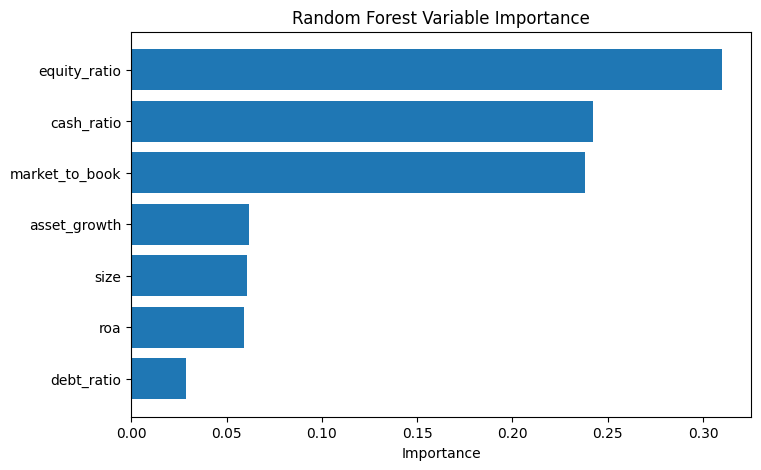

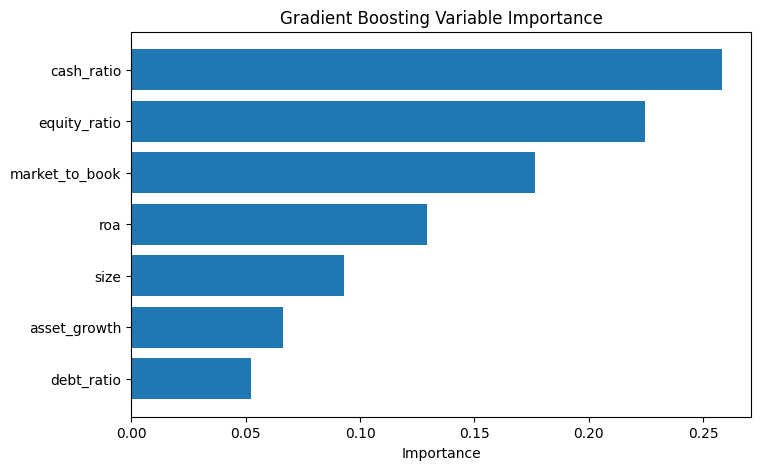

In [53]:
# =========================================================
# Cell 19. 변수 중요도
# =========================================================

if "ml_models" in globals() and len(ml_models) > 0:

    rf = ml_models["RandomForest"]
    gb = ml_models["GradientBoosting"]

    rf_importance = pd.DataFrame({
        "variable": x_vars_main,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    gb_importance = pd.DataFrame({
        "variable": x_vars_main,
        "importance": gb.feature_importances_
    }).sort_values("importance", ascending=False)

    display(rf_importance)
    display(gb_importance)

    plt.figure(figsize=(8, 5))
    plt.barh(rf_importance["variable"], rf_importance["importance"])
    plt.gca().invert_yaxis()
    plt.title("Random Forest Variable Importance")
    plt.xlabel("Importance")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.barh(gb_importance["variable"], gb_importance["importance"])
    plt.gca().invert_yaxis()
    plt.title("Gradient Boosting Variable Importance")
    plt.xlabel("Importance")
    plt.show()

else:
    rf_importance = pd.DataFrame()
    gb_importance = pd.DataFrame()
    print("ML 모델이 없어 변수 중요도 생략.")

In [54]:
# =========================================================
# Cell 20. 논문용 요약표 생성
# =========================================================

summary_vars = [main_y] + x_vars_main

summary_stats = reg_main[summary_vars].describe().T
summary_stats["missing_count"] = reg_main[summary_vars].isna().sum()
summary_stats["missing_ratio"] = reg_main[summary_vars].isna().mean()

corr_matrix = reg_main[summary_vars].corr()

print("Summary Statistics")
display(summary_stats)

print("Correlation Matrix")
display(corr_matrix)

# 회귀표 wide format
def make_regression_wide_table(ols_tables):
    temp = ols_tables.copy()
    temp["coef_line"] = temp["coef"].map(lambda x: f"{x:.4f}") + temp["stars"]
    temp["t_line"] = temp["t_stat"].map(lambda x: f"({x:.2f})")

    coef_wide = temp.pivot(index="variable", columns="model", values="coef_line")
    t_wide = temp.pivot(index="variable", columns="model", values="t_line")

    rows = []
    for var in coef_wide.index:
        rows.append(pd.DataFrame(coef_wide.loc[[var]]))
        t_row = pd.DataFrame(t_wide.loc[[var]])
        t_row.index = [var + "_t"]
        rows.append(t_row)

    out = pd.concat(rows)
    return out

main_regression_table_wide = make_regression_wide_table(ols_tables)

print("Main Regression Table Wide")
display(main_regression_table_wide)

Summary Statistics


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_ratio
vw_adj_cum_ret_202203_202303,340.00000,-0.01514,0.20708,-0.64258,-0.14738,-0.01431,0.11810,0.46783,0,0.00000
size,340.00000,8.58988,1.52018,5.78212,7.52809,8.36380,9.46653,13.24718,0,0.00000
equity_ratio,340.00000,0.10801,0.03118,0.06279,0.08913,0.10142,0.11767,0.26352,0,0.00000
roa,340.00000,0.01132,0.00403,-0.00013,0.00882,0.01136,0.01372,0.02155,0,0.00000
cash_ratio,340.00000,0.10868,0.07894,0.00897,0.04871,0.09014,0.14555,0.37577,0,0.00000
debt_ratio,340.00000,0.04456,0.03683,0.00002,0.02061,0.03488,0.05767,0.18322,0,0.00000
asset_growth,340.00000,0.14937,0.18239,-0.06852,0.05155,0.09871,0.17558,1.01630,0,0.00000
market_to_book,340.00000,1.29592,0.47007,0.68089,1.02787,1.18923,1.38095,3.50865,0,0.00000


Correlation Matrix


,vw_adj_cum_ret_202203_202303,size,equity_ratio,roa,cash_ratio,debt_ratio,asset_growth,market_to_book
vw_adj_cum_ret_202203_202303,1.00000,-0.18037,0.05613,-0.00817,0.18556,-0.12540,-0.10462,-0.23705
size,-0.18037,1.00000,-0.23297,0.18920,0.05272,0.12957,-0.00344,0.29539
equity_ratio,0.05613,-0.23297,1.00000,-0.02745,-0.06271,0.02963,-0.10741,-0.21364
roa,-0.00817,0.18920,-0.02745,1.00000,-0.09521,-0.03168,-0.17613,0.33120
cash_ratio,0.18556,0.05272,-0.06271,-0.09521,1.00000,-0.13092,0.23362,0.10498
debt_ratio,-0.12540,0.12957,0.02963,-0.03168,-0.13092,1.00000,-0.18246,0.04295
asset_growth,-0.10462,-0.00344,-0.10741,-0.17613,0.23362,-0.18246,1.00000,0.18941
market_to_book,-0.23705,0.29539,-0.21364,0.33120,0.10498,0.04295,0.18941,1.00000


Main Regression Table Wide


model,M1_basic,M2_balance_sheet,M3_full
asset_growth,NaN,-0.1961**,-0.1348*
asset_growth_t,NaN,(-2.33),(-1.79)
cash_ratio,NaN,0.5871***,0.6332***
cash_ratio_t,NaN,(3.69),(4.25)
const,0.1720*,0.1680*,0.2067**
const_t,(1.89),(1.73),(2.12)
debt_ratio,NaN,-0.5872**,-0.4750
debt_ratio_t,NaN,(-2.02),(-1.56)
equity_ratio,0.0959,0.0893,-0.1156
equity_ratio_t,(0.22),(0.19),(-0.25)


In [55]:
# =========================================================
# Cell 21. 최종 결과 전체 저장 + GPT 분석용 ZIP 생성
# =========================================================

output_folder = r"C:\Users\starw\OneDrive\바탕 화면\학교 생활\UNIST\Research\박지훈 자료\strict_bank_analysis_output"
os.makedirs(output_folder, exist_ok=True)

saved_files = []

def save_df(obj, filename, index=False):
    if obj is not None and isinstance(obj, pd.DataFrame):
        path = os.path.join(output_folder, filename)
        obj.to_csv(path, index=index, encoding="utf-8-sig")
        saved_files.append(path)
        print(f"저장 완료: {filename}")

def save_txt(text, filename):
    path = os.path.join(output_folder, filename)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)
    saved_files.append(path)
    print(f"저장 완료: {filename}")

# ---------------------------------------------------------
# 1. 주요 데이터 저장
# ---------------------------------------------------------

save_df(funda_bank_raw, "01_funda_strict_bank_raw_2020_2021.csv")
save_df(x_data, "02_pre_shock_accounting_variables_2021.csv")
save_df(crsp_info, "03_crsp_security_info.csv")
save_df(bank_bench, "04_monthly_bank_benchmark_returns.csv")
save_df(linked_monthly, "05_linked_monthly_returns_with_accounting.csv")
save_df(y_main, "06_y_main_202203_202303.csv")
save_df(y_extended, "07_y_extended_202203_202307.csv")
save_df(y_march, "08_y_march_202303.csv")
save_df(analysis_df, "09_merged_analysis_data.csv")
save_df(reg_df, "10_regression_data_all.csv")
save_df(reg_main, "11_final_main_regression_sample.csv")

# ---------------------------------------------------------
# 2. 결과표 저장
# ---------------------------------------------------------

save_df(summary_stats, "12_summary_statistics.csv", index=True)
save_df(corr_matrix, "13_correlation_matrix.csv", index=True)
save_df(ols_tables, "14_main_ols_results_long.csv")
save_df(ols_fit, "15_main_ols_fit.csv")
save_df(main_regression_table_wide, "16_main_regression_table_wide.csv", index=True)
save_df(robust_ols_tables, "17_robustness_ols_results_long.csv")
save_df(robust_ols_fit, "18_robustness_ols_fit.csv")
save_df(commercial_tables, "19_commercial_bank_only_results.csv")
save_df(commercial_fit, "20_commercial_bank_only_fit.csv")
save_df(ml_results, "21_ml_results_appendix.csv")
save_df(rf_importance, "22_random_forest_importance.csv")
save_df(gb_importance, "23_gradient_boosting_importance.csv")

# ---------------------------------------------------------
# 3. OLS full summary 저장
# ---------------------------------------------------------

if "ols1" in globals():
    save_txt(ols1.summary().as_text(), "24_ols1_basic_full_summary.txt")

if "ols2" in globals():
    save_txt(ols2.summary().as_text(), "25_ols2_balance_sheet_full_summary.txt")

if "ols3" in globals():
    save_txt(ols3.summary().as_text(), "26_ols3_full_model_summary.txt")

if "robust_models" in globals():
    for name, model in robust_models.items():
        save_txt(model.summary().as_text(), f"27_{name}_summary.txt")

if "commercial_models" in globals() and len(commercial_models) > 0:
    for name, model in commercial_models.items():
        save_txt(model.summary().as_text(), f"28_{name}_summary.txt")

# ---------------------------------------------------------
# 4. GPT용 요약 텍스트 생성
# ---------------------------------------------------------

summary_txt = ""

summary_txt += "Strict Bank Research Project Summary for GPT Analysis\n"
summary_txt += "=" * 90 + "\n\n"

summary_txt += "Project Title Candidate:\n"
summary_txt += "Balance Sheet Fragility and Bank Stock Performance During the 2022-2023 Interest Rate Shock\n\n"

summary_txt += "Research Question:\n"
summary_txt += "Do pre-shock bank balance sheet characteristics predict bank stock performance during the 2022-2023 interest rate shock?\n\n"

summary_txt += "Key Improvements in This Version:\n"
summary_txt += "1. Main sample excludes SIC 6099 and keeps only SIC 6020, 6035, and 6036.\n"
summary_txt += "2. Delisting returns are incorporated using ret_adj = (1 + RET) * (1 + DLRET) - 1.\n"
summary_txt += "3. Main dependent variable uses value-weighted bank benchmark adjusted cumulative return.\n"
summary_txt += "4. Equal-weight adjusted returns, raw returns, March 2023 returns, extended-period returns, and maximum drawdown are used as robustness outcomes.\n"
summary_txt += "5. Commercial-bank-only sample using SIC 6020 is included as an additional robustness test.\n\n"

summary_txt += "Sample Definition:\n"
summary_txt += "U.S. publicly traded banks from Compustat annual data using SIC 6020, 6035, and 6036.\n"
summary_txt += "Accounting predictors are measured using fiscal year 2021 data.\n\n"

summary_txt += "Main Dependent Variable:\n"
summary_txt += f"{main_y}\n"
summary_txt += "This is the cumulative delisting-adjusted stock return from 2022-03 to 2023-03 minus the value-weighted bank benchmark return.\n\n"

summary_txt += "Main Explanatory Variables:\n"
for v in x_vars_main:
    summary_txt += f"- {v}\n"
summary_txt += "\n"

summary_txt += "Final Sample Information:\n"
summary_txt += f"reg_main rows: {reg_main.shape[0]}\n"
summary_txt += f"reg_main columns: {reg_main.shape[1]}\n"
summary_txt += f"unique gvkey: {reg_main['gvkey'].nunique() if 'gvkey' in reg_main.columns else 'NA'}\n"
summary_txt += f"unique PERMNO: {reg_main['PERMNO'].nunique() if 'PERMNO' in reg_main.columns else 'NA'}\n\n"

summary_txt += "SIC Distribution:\n"
summary_txt += reg_main["sich_num"].value_counts().sort_index().to_string()
summary_txt += "\n\n"

summary_txt += "Summary Statistics:\n"
summary_txt += summary_stats.to_string()
summary_txt += "\n\n"

summary_txt += "Correlation Matrix:\n"
summary_txt += corr_matrix.to_string()
summary_txt += "\n\n"

summary_txt += "Main OLS Fit:\n"
summary_txt += ols_fit.to_string(index=False)
summary_txt += "\n\n"

summary_txt += "Main OLS Results:\n"
summary_txt += ols_tables.to_string(index=False)
summary_txt += "\n\n"

summary_txt += "Robustness OLS Fit:\n"
summary_txt += robust_ols_fit.to_string(index=False) if len(robust_ols_fit) > 0 else "No robustness results.\n"
summary_txt += "\n\n"

summary_txt += "Robustness OLS Results:\n"
summary_txt += robust_ols_tables.to_string(index=False) if len(robust_ols_tables) > 0 else "No robustness results.\n"
summary_txt += "\n\n"

summary_txt += "Commercial Bank Only Results:\n"
summary_txt += commercial_tables.to_string(index=False) if len(commercial_tables) > 0 else "No commercial-only results.\n"
summary_txt += "\n\n"

summary_txt += "ML Results Appendix:\n"
summary_txt += ml_results.to_string(index=False) if len(ml_results) > 0 else "No ML results.\n"
summary_txt += "\n\n"

summary_txt += "Random Forest Importance:\n"
summary_txt += rf_importance.to_string(index=False) if len(rf_importance) > 0 else "No RF importance.\n"
summary_txt += "\n\n"

summary_txt += "Gradient Boosting Importance:\n"
summary_txt += gb_importance.to_string(index=False) if len(gb_importance) > 0 else "No GB importance.\n"

save_txt(summary_txt, "00_strict_bank_research_summary_for_gpt.txt")

# ---------------------------------------------------------
# 5. Excel 파일 저장
# ---------------------------------------------------------

excel_path = os.path.join(output_folder, "strict_bank_research_outputs_for_gpt.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    reg_main.to_excel(writer, sheet_name="final_sample", index=False)
    summary_stats.to_excel(writer, sheet_name="summary_stats")
    corr_matrix.to_excel(writer, sheet_name="correlation")
    ols_tables.to_excel(writer, sheet_name="main_ols", index=False)
    ols_fit.to_excel(writer, sheet_name="main_ols_fit", index=False)
    main_regression_table_wide.to_excel(writer, sheet_name="regression_wide")

    if len(robust_ols_tables) > 0:
        robust_ols_tables.to_excel(writer, sheet_name="robust_ols", index=False)

    if len(robust_ols_fit) > 0:
        robust_ols_fit.to_excel(writer, sheet_name="robust_fit", index=False)

    if len(commercial_tables) > 0:
        commercial_tables.to_excel(writer, sheet_name="commercial_only", index=False)

    if len(ml_results) > 0:
        ml_results.to_excel(writer, sheet_name="ml_results", index=False)

    if len(rf_importance) > 0:
        rf_importance.to_excel(writer, sheet_name="rf_importance", index=False)

    if len(gb_importance) > 0:
        gb_importance.to_excel(writer, sheet_name="gb_importance", index=False)

saved_files.append(excel_path)
print(f"저장 완료: {excel_path}")

# ---------------------------------------------------------
# 6. ZIP 압축
# ---------------------------------------------------------

zip_path = os.path.join(output_folder, "strict_bank_research_outputs_for_gpt.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in saved_files:
        if os.path.exists(file_path):
            zipf.write(file_path, arcname=os.path.basename(file_path))

print("\n압축 완료:")
print(zip_path)

print("\n" + "=" * 100)
print("GPT에게 업로드할 파일")
print("=" * 100)
print(zip_path)

print("\n업로드 후 이렇게 말하면 됩니다:")
print("""
이 압축파일은 문제점을 개선한 strict bank sample 분석 결과야.
SIC 6099를 제거하고, SIC 6020/6035/6036만 사용했고,
RET와 DLRET를 결합했고,
value-weighted bank-adjusted return을 메인 Y로 사용했어.
결과를 보고:
1. 연구 결과 해석
2. 이전 결과와 비교
3. 논문 표 구성
4. 아직 남은 문제점
5. 교수님께 보고할 요약
6. 다음 분석 코드
를 알려줘.
""")

저장 완료: 01_funda_strict_bank_raw_2020_2021.csv
저장 완료: 02_pre_shock_accounting_variables_2021.csv
저장 완료: 03_crsp_security_info.csv
저장 완료: 04_monthly_bank_benchmark_returns.csv
저장 완료: 05_linked_monthly_returns_with_accounting.csv
저장 완료: 06_y_main_202203_202303.csv
저장 완료: 07_y_extended_202203_202307.csv
저장 완료: 08_y_march_202303.csv
저장 완료: 09_merged_analysis_data.csv
저장 완료: 10_regression_data_all.csv
저장 완료: 11_final_main_regression_sample.csv
저장 완료: 12_summary_statistics.csv
저장 완료: 13_correlation_matrix.csv
저장 완료: 14_main_ols_results_long.csv
저장 완료: 15_main_ols_fit.csv
저장 완료: 16_main_regression_table_wide.csv
저장 완료: 17_robustness_ols_results_long.csv
저장 완료: 18_robustness_ols_fit.csv
저장 완료: 19_commercial_bank_only_results.csv
저장 완료: 20_commercial_bank_only_fit.csv
저장 완료: 21_ml_results_appendix.csv
저장 완료: 22_random_forest_importance.csv
저장 완료: 23_gradient_boosting_importance.csv
저장 완료: 24_ols1_basic_full_summary.txt
저장 완료: 25_ols2_balance_sheet_full_summary.txt
저장 완료: 26_ols3_full_model_summa